# Analyse statistique sur les développeurs selon l'enquête menée par Stack Overflow

Le but ici est de répondre à 5 questions business et de les représenter graphiquement. Les questions sont les suivantes :
1. Quels langages dominent le marché en 2023 ?
2. Quels rôles sont les mieux rémunérés ?
3. Quelles technologies émergent (want vs have) ?
4. Le diplôme est-il obligatoire pour devenir développeur ?
5. Les cours en ligne sont-ils la meilleure façon de se former ?

# Importation des outils de travail

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset

In [3]:
#Chargement du dataset
df = pd.read_csv('archive/survey_results_public.csv')

# Exploration du dataset

### Nombre de lignes et de colonnes du dataset

In [4]:
df.shape

(89184, 84)

### Noms des colonnes du dataset

In [5]:
df.columns.tolist()

['ResponseId',
 'Q120',
 'MainBranch',
 'Age',
 'Employment',
 'RemoteWork',
 'CodingActivities',
 'EdLevel',
 'LearnCode',
 'LearnCodeOnline',
 'LearnCodeCoursesCert',
 'YearsCode',
 'YearsCodePro',
 'DevType',
 'OrgSize',
 'PurchaseInfluence',
 'TechList',
 'BuyNewTool',
 'Country',
 'Currency',
 'CompTotal',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'OfficeStackAsyncHaveWorkedWith',
 'OfficeStackAsyncWantToWorkWith',
 'OfficeStackSyncHaveWorkedWith',
 'OfficeStackSyncWantToWorkWith',
 'AISearchHaveWorkedWith',
 'AISearchWantToWorkWith',
 'AIDevHaveWorkedWith',
 'AIDevWantToWorkWith',
 'NEWSO

### Statistiques descriptives par colonne

In [6]:
df.describe()

,ResponseId,CompTotal,WorkExp,ConvertedCompYearly
count,89184.000000,4.822500e+04,43579.000000,4.801900e+04
mean,44592.500000,1.036807e+42,11.405126,1.031101e+05
std,25745.347541,2.276847e+44,9.051989,6.814188e+05
min,1.000000,0.000000e+00,0.000000,1.000000e+00
25%,22296.750000,6.300000e+04,5.000000,4.390700e+04
50%,44592.500000,1.150000e+05,9.000000,7.496300e+04
75%,66888.250000,2.300000e+05,16.000000,1.216410e+05
max,89184.000000,5.000000e+46,50.000000,7.435143e+07


### Aperçu des 5 premières lignes du dataset

In [7]:
df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


### Types de données et valeurs manquantes

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89184 non-null  int64  
 1   Q120                                 89184 non-null  object 
 2   MainBranch                           89184 non-null  object 
 3   Age                                  89184 non-null  object 
 4   Employment                           87898 non-null  object 
 5   RemoteWork                           73810 non-null  object 
 6   CodingActivities                     73764 non-null  object 
 7   EdLevel                              87973 non-null  object 
 8   LearnCode                            87663 non-null  object 
 9   LearnCodeOnline                      70084 non-null  object 
 10  LearnCodeCoursesCert                 37076 non-null  object 
 11  YearsCode                   

## Distribution des valeurs pour la colonne `LanguageHaveWorkedWith`

In [9]:

df['LanguageHaveWorkedWith'].value_counts().head(10)

LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript           1487
Python                                   1132
HTML/CSS;JavaScript                       735
HTML/CSS;JavaScript;PHP;SQL               718
C#                                        649
JavaScript;TypeScript                     590
C#;HTML/CSS;JavaScript;SQL;TypeScript     575
Java                                      573
Python;SQL                                460
C#;HTML/CSS;JavaScript;SQL                449
Name: count, dtype: int64

In [10]:
df['DevType'].value_counts().head(10)

DevType
Developer, full-stack                            25735
Developer, back-end                              13745
Developer, front-end                              5071
Developer, desktop or enterprise applications     3904
Other (please specify):                           3080
Developer, mobile                                 2597
Engineering manager                               2033
Student                                           1996
Developer, embedded applications or devices       1845
Data scientist or machine learning specialist     1588
Name: count, dtype: int64

In [11]:
df['ConvertedCompYearly'].describe()

count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64

In [12]:

df['ConvertedCompYearly'].median()

74963.0

In [13]:
df['LanguageWantToWorkWith'].value_counts().head(10)

LanguageWantToWorkWith
Rust                              1438
Python                            1182
HTML/CSS;JavaScript;TypeScript    1071
C#                                 736
Go                                 618
TypeScript                         493
JavaScript;TypeScript              451
Java                               450
Python;Rust                        446
Python;SQL                         424
Name: count, dtype: int64

### Nettoyage des valeurs aberrantes du salaire annuel converti

On filtre les salaires inférieurs à 10 000 $/an et supérieurs à 300 000 $/an car il s'agit de données suspectes ou d'outliers extrêmes. C'est un choix analytique assumé.

In [14]:

df_clean = df[
    (df['ConvertedCompYearly'] > 10000) & 
    (df['ConvertedCompYearly'] < 300000)
]

In [15]:
df_clean['ConvertedCompYearly'].median()

78069.0

In [16]:
#Il y a des valeurs manquantes dans la colonne "DevType". Utilisons dropna() pour les ignorer et accéder à la première valeur non nulle.
df['DevType'].dropna().iloc[0]


'Senior Executive (C-Suite, VP, etc.)'

In [17]:
#Les grans mots, les grans moyens
df['DevType'].dropna().str.contains(';').sum()

np.int64(0)

In [18]:
salary_by_role = df_clean.groupby('DevType')['ConvertedCompYearly'].median().sort_values(ascending=False)

salary_by_role.head(10)

DevType
Engineering manager                     120000.0
Senior Executive (C-Suite, VP, etc.)    115028.0
Engineer, site reliability              112444.0
Developer Experience                    106229.0
Blockchain                              104630.0
Cloud infrastructure engineer           103525.0
Developer Advocate                       99593.0
Security professional                    98522.0
Marketing or sales professional          95700.0
Scientist                                93486.0
Name: ConvertedCompYearly, dtype: float64

In [19]:
#Ok, je vais les langauges populaire mais un mem dev peut en selct pluseirus separe par ;
df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts().head(10).sort_values(ascending=False)

LanguageHaveWorkedWith
JavaScript                 55711
HTML/CSS                   46396
Python                     43158
SQL                        42623
TypeScript                 34041
Bash/Shell (all shells)    28351
Java                       26757
C#                         24193
C++                        19634
C                          16940
Name: count, dtype: int64

In [20]:
#Quelles sont les technos emergentes ? Lesquelles sont les plus populaires ?
top10technoemergente = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().head(10).sort_values(ascending=False)


- Go et Rust — deux langages systèmes modernes qui montent fort.
- **Insight business :** Rust est plébiscité pour la performance et la sécurité mémoire. Go pour les systèmes distribués et le cloud. Leur absence dans le top 10 "have" mais présence dans le top 10 "want" = adoption en cours, pas encore mainstream. C'est ce qu'on appelle un *leading indicator* — les tendances de 2025-2026.
- Note : Python grimpe de la 3ème à la 2ème place entre "have" et "want" — la demande pour Python s'accélère encore.

In [21]:
structured_type = df_clean.groupby('DevType')['ConvertedCompYearly'].agg(
    salaire_median='median',
    salaire_moyen='mean',
    nb_repondants='count'
)

# Filtrer les rôles avec plus de 200 répondants
structured_type_filtered = structured_type[structured_type['nb_repondants'] > 200]
structured_type_filtered.sort_values(by='salaire_median', ascending=False).head(5)

#Insight clé : Les 3 premiers rôles sont du management ou de l'infrastructure critique — pas du pur analytique. Le message est clair : la technique seule plafonne. Leadership + technique = salaires premium.
#Pour toi concrètement : Data Analyst → Senior Analyst → Analytics Manager. C'est le chemin vers les 100k$+.

,salaire_median,salaire_moyen,nb_repondants
DevType,,,
Engineering manager,120000.0,128194.073311,1214
"Senior Executive (C-Suite, VP, etc.)",115028.0,129196.937407,671
"Engineer, site reliability",112444.0,123751.550523,287
Cloud infrastructure engineer,103525.0,115718.367751,707
Security professional,98522.0,115756.075117,213


## Visualisation : Rôles les mieux rémunérés

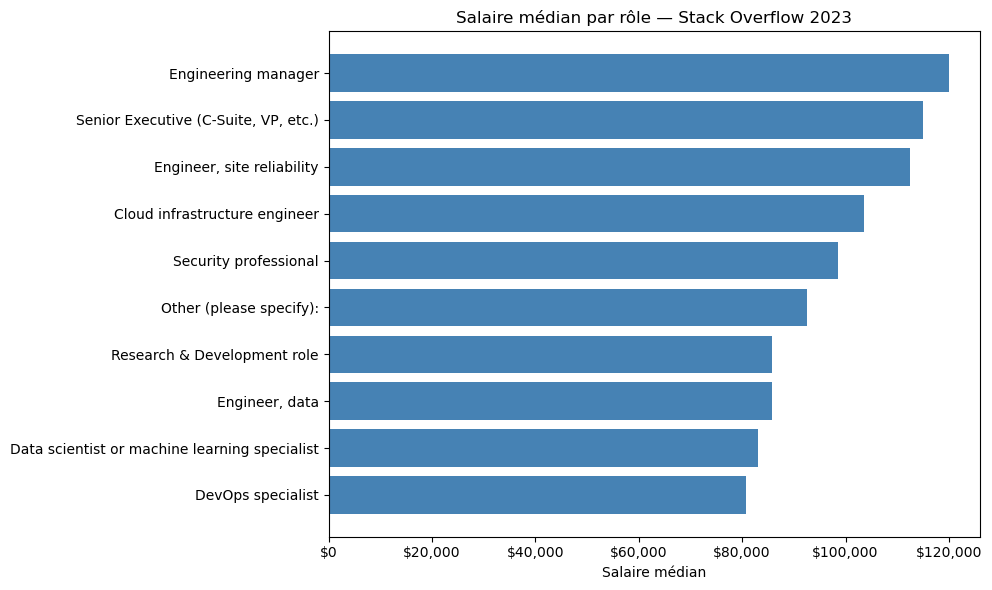

In [22]:
top10 = structured_type_filtered.sort_values(
    'salaire_median', ascending=True
).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10['salaire_median'], color='steelblue')
plt.xlabel("Salaire médian")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.title("Salaire médian par rôle — Stack Overflow 2023")
plt.tight_layout()
plt.show()

### Insights

Les métiers qui requièrent du management sont mieux rémunérés que les rôles purement techniques. Cela démontre que la valeur en entreprise ne repose pas uniquement sur la technique : la capacité à gérer des équipes et des budgets est davantage valorisée.

## Visualisation : Technologies émergentes

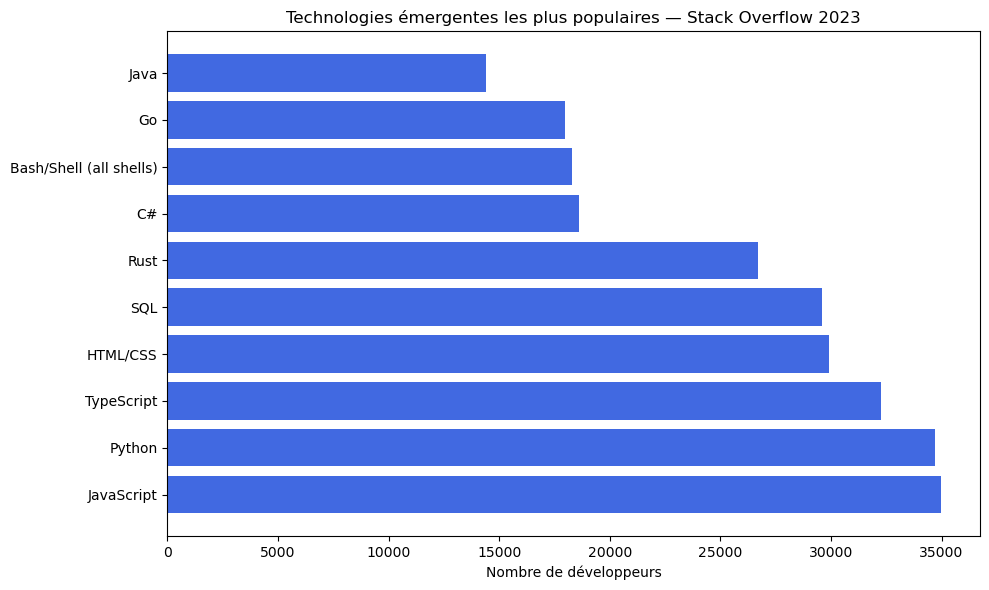

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(top10technoemergente.index, top10technoemergente.values, color='royalblue')
plt.xlabel("Nombre de développeurs")

plt.title("Technologies émergentes les plus populaires — Stack Overflow 2023")
plt.tight_layout()
plt.show()


### Insights

JavaScript et Python dominent aussi le classement des langages souhaités, ce qui confirme leur position centrale dans l'écosystème. La montée de Rust et Go traduit un besoin croissant de systèmes performants et sécurisés — notamment pour le cloud et les applications critiques.

## Visualisation : Technologies les plus utilisées

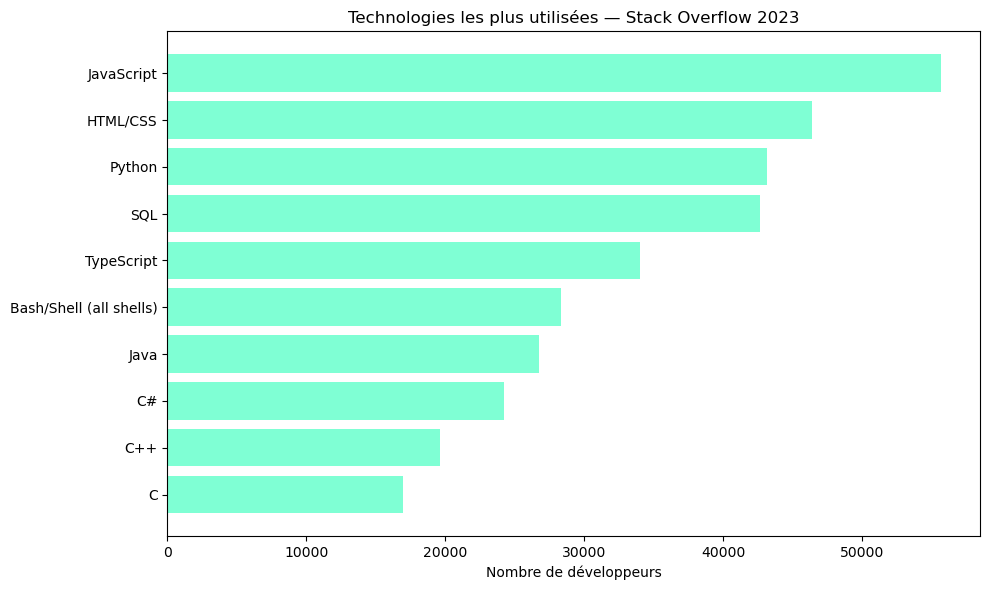

In [24]:
top10TechnoUtilise = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10TechnoUtilise.index, top10TechnoUtilise.values, color='aquamarine')
plt.xlabel("Nombre de développeurs")
plt.title("Technologies les plus utilisées — Stack Overflow 2023")
plt.tight_layout()
plt.show()

### Insights

JavaScript reste clairement en tête avec HTML/CSS, ce qui confirme la domination du développement web. Python et SQL complètent le podium, reflétant l'importance croissante de la data dans les pratiques de développement.

## Visualisation : Niveau de formation des développeurs

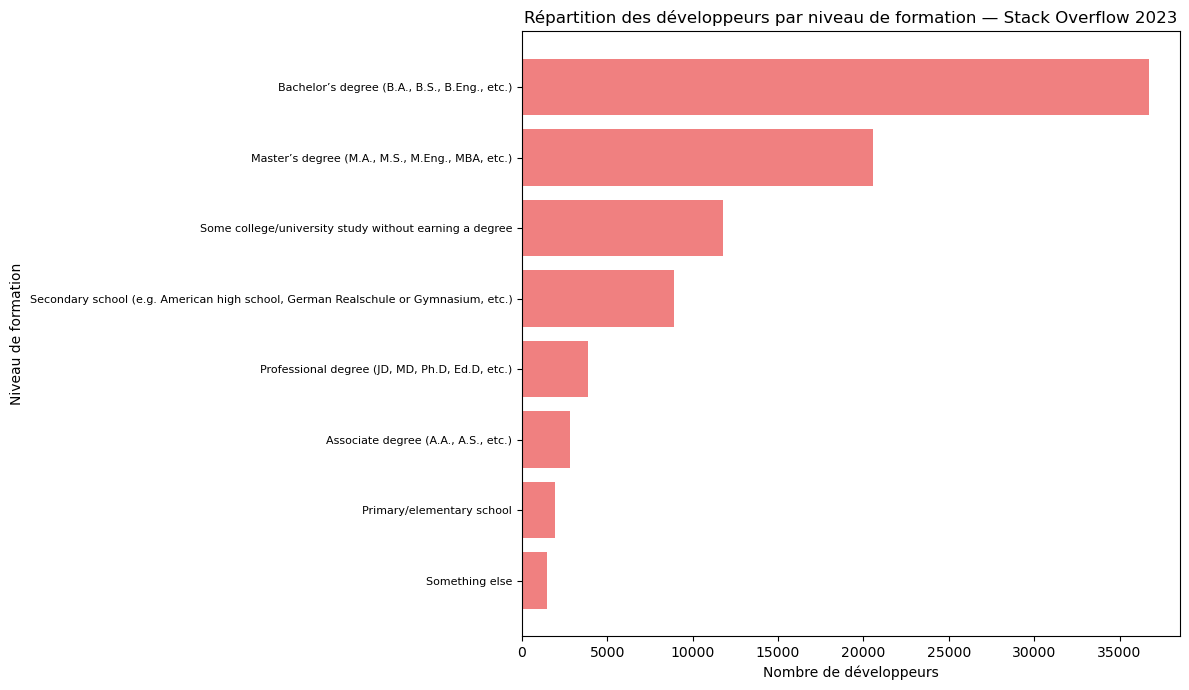

In [25]:
repartitionNiveauDev = df['EdLevel'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(repartitionNiveauDev.index, repartitionNiveauDev.values, color='lightcoral')
plt.xlabel("Nombre de développeurs")
plt.ylabel("Niveau de formation")
plt.title("Répartition des développeurs par niveau de formation — Stack Overflow 2023")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Insights

La majorité des développeurs détiennent un Bachelor (licence) soit plus de 35k développeur, suivi du Master entre 20000 et 25000. On note également une proportion non négligeable de développeurs sans diplôme formel, ce qui nuance l'idée que le diplôme soit indispensable pour intégrer le secteur(entre 0 et 5000).

## Visualisation : Méthodes d'apprentissage des développeurs

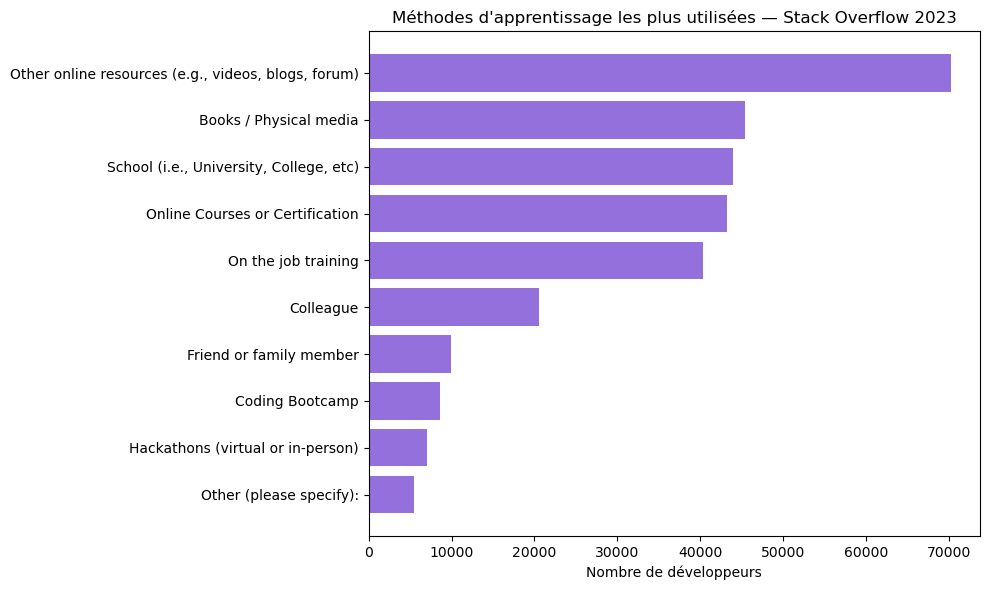

In [27]:
top = df['LearnCode'].dropna().str.split(';').explode().value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top.index, top.values, color='mediumpurple')
plt.xlabel("Nombre de développeurs")
plt.title("Méthodes d'apprentissage les plus utilisées — Stack Overflow 2023")
plt.tight_layout()
plt.show()

### Insights

L'apprentissage en ligne (ressources informelles + cours certifiants combinés) représente globalement la méthode la plus répandue — mais les livres, l'école et la formation sur le tas restent très présents dans le top 5. Un développeur polyvalent ne peut pas miser sur une seule méthode : diversifier ses sources d'apprentissage est une nécessité, pas un avantage.
